# RB-F08：MLMC・RQMCの誤差と費用

保存artifactだけを読み、固定pilot配分・独立run RMSE・Student近似CIを比較します。ノート内で新しいpath、scramble、bootstrap、学習を生成しません。

In [1]:
import importlib.util
import json
import os
import sys
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter
from hullkit import nbplot

get_ipython().run_line_magic("matplotlib", "inline")
plt = nbplot.setup()
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

def resolve_directory(variable, filename):
    supplied = os.environ.get(variable)
    candidates = [Path(supplied)] if supplied else [Path.cwd()]
    if not supplied:
        candidates += [parent / "johnhull/research/RB-F08"
                       for parent in [Path.cwd(), *Path.cwd().parents]]
    for candidate in candidates:
        if (candidate / filename).is_file():
            return candidate
    raise FileNotFoundError("Saved RB-F08 data/source missing; set " + variable)

artifact_dir = resolve_directory("JOHNHULL_MLMC_ARTIFACTS_DIR", "reference.json")
source_dir = resolve_directory("JOHNHULL_MLMC_SOURCE_DIR", "build_reference.py")
spec = importlib.util.spec_from_file_location("rbf08_saved_loader", source_dir / "build_reference.py")
loader = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = loader
spec.loader.exec_module(loader)
record, arrays = loader.load_result(artifact_dir)
checked = loader.check_record(record, arrays, fresh=False)
if checked.get("passed") is not True:
    raise ValueError("Saved RB-F08 observations failed their numerical checker")
protocol = record["protocol"]
mode = record["mode"]
pilot = (loader._read_snapshot(arrays, "pilot_record_snapshot")
         if "pilot_record_snapshot" in arrays else None)
decision = record["decision"]
costs = record["costs"]
fresh_cost = loader.fresh_receipts(artifact_dir, record)
names = ["mlmc", "plain_euler", "exact_plain", "exact_cv"]
labels = {"mlmc": "Euler MLMC", "plain_euler": "plain Euler",
          "exact_plain": "exact terminal", "exact_cv": "fixed-pilot CV"}
colors = dict(zip(names, ["tab:blue", "tab:orange", "tab:green", "tab:red"]))
status = "Euler speed evidence" if decision["speedup_supported_vs_euler"] else "Euler speed not supported"

def number(value):
    return "unsupported" if value is None else f"{value:.6g}"

def table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |",
             "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def finish_figure(fig, title):
    fig.suptitle(title + " | " + mode + " | " + status, fontsize=12)
    fig.tight_layout(rect=(0, .045, 1, .95))
    display(fig)
    plt.close(fig)

print("Saved-artifact mode:", mode, "| checked:", checked["passed"])
if mode == "fixture":
    print("fixture / 未受入: 表示配線の確認専用。研究の数値成果や独立受入ではありません。")
else:
    print("主計算の保存値。計算checkerの合格と研究の独立受入は別で、受入記録はREADME/REVIEWが正本です。")
print("Student CIは近似。sampling CIはEuler期待値を対象にし、BSM真値への被覆にはbiasが入ります。")
print("No financial path generation, Sobol sampling, bootstrap RNG, learning, or fresh experiment.")
print("seed ledger:", protocol["seed_ledger_meta"]["count"], "physical seeds;",
      "unique seeds prevent reuse but do not prove mathematical independence.")
print("clip:", protocol["rqmc"]["clip"]["lower"], protocol["rqmc"]["clip"]["upper"])
print("RQMC nominal confidence:", protocol["rqmc"]["confidence"],
      "| sample unit: independent scramble means | df = R-1")
print("独立runの元の分母:", record["main_repetitions"],
      "| RQMC元のouter分母:", record["coverage_repetitions"])
print("採否: teaching_candidate =", decision["teaching_candidate"],
      "; speedup_supported_vs_euler =", decision["speedup_supported_vs_euler"],
      "; final research acceptance is separate.")
for reason in decision["rejection_reasons"]:
    print("採否理由:", reason)
print("失敗cell:", decision["failed_cells"])
print("coldは、この凍結研究pipelineの検証込み初回費用です。全pilot・台帳検証を含みます。")
print("Cold: initial validated cost of this frozen research pipeline, including pilot and ledger validation.")
print("Exact terminal / BSM単独に数学的に必要な起動費用の最小値ではありません。")
print("main-only秒と独立BSM単回秒を別記します。BSM単回秒は記述値で、benchmark保証ではありません。")
print("Recorded categorized research cost before fresh (not total CLI wall time):",
      number(costs.get("full_research_s_before_fresh")),
      "| fresh receipt seconds:", number(fresh_cost["total_s"]), "| pending:", fresh_cost["pending"])
print("カテゴリ合計にはpost-run check・decision・JSON書出し・startup等の未記録段階があります。CLI総wallとは区別します。")
wall_path = artifact_dir / "main_execution_wall.json"
if wall_path.is_file():
    wall_receipt = json.loads(wall_path.read_text())
    if wall_receipt.get("reference_record_digest") != loader.module("protocol").json_digest(record):
        raise ValueError("Main execution wall receipt does not bind this saved reference record")
    wall_seconds = float(wall_receipt["wall_s"])
    overhead_seconds = float(wall_receipt["unaccounted_overhead_s"])
    if not np.isfinite([wall_seconds, overhead_seconds]).all() or wall_seconds < 0:
        raise ValueError("Main execution wall receipt contains invalid seconds")
    print("Independent main CLI stopwatch wall_s:", number(wall_seconds),
          "| unaccounted_overhead_s:", number(overhead_seconds))
    print("CLI wall scope:", wall_receipt.get("scope", "main command including unrecorded stages"))
else:
    print("Independent main CLI stopwatch receipt: pending (main_execution_wall.json absent).")
allocation_rows = []
for row in record["allocations"]:
    allocation_rows.append([row["epsilon"], row["status"], row["level"], row["mlmc_paths"],
                            row["plain_euler_paths"], row["exact_plain_paths"], row["exact_cv_paths"],
                            number(row["bias_bound"]), row.get("reason")])
table(["epsilon", "Euler状態", "L", "MLMC N_l", "plain Euler N", "exact N", "CV N",
       "経験的bias envelope", "理由"], allocation_rows)


Saved-artifact mode: main | checked: True
主計算の保存値。計算checkerの合格と研究の独立受入は別で、受入記録はREADME/REVIEWが正本です。
Student CIは近似。sampling CIはEuler期待値を対象にし、BSM真値への被覆にはbiasが入ります。
No financial path generation, Sobol sampling, bootstrap RNG, learning, or fresh experiment.
seed ledger: 181729 physical seeds; unique seeds prevent reuse but do not prove mathematical independence.
clip: 5e-324 0.9999999999999999
RQMC nominal confidence: 0.95 | sample unit: independent scramble means | df = R-1
独立runの元の分母: 256 | RQMC元のouter分母: 512
採否: teaching_candidate = True ; speedup_supported_vs_euler = True ; final research acceptance is separate.
採否理由: epsilon=0.4: exact terminal comparator is faster
採否理由: epsilon=0.4: cold pilot-inclusive cost loses to exact terminal
採否理由: epsilon=0.2: exact terminal comparator is faster
採否理由: epsilon=0.2: cold pilot-inclusive cost loses to exact terminal
採否理由: epsilon=0.1: exact terminal comparator is faster
採否理由: epsilon=0.1: cold pilot-inclusive cost loses to exact terminal
失敗cell: {

| epsilon | Euler状態 | L | MLMC N_l | plain Euler N | exact N | CV N | 経験的bias envelope | 理由 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0.4 | ready | 2 | [2670, 118, 71] | 2403 | 2533 | 425 | 0.0110855 | None |
| 0.2 | ready | 2 | [10680, 472, 284] | 9611 | 10131 | 1699 | 0.0110855 | None |
| 0.1 | ready | 2 | [42720, 1888, 1133] | 38442 | 40521 | 6793 | 0.0110855 | None |

## 1. 階層差分分散・bias・負状態

alpha windows: [] | beta: [{'beta': 8.209782899002793, 'coarse': 0, 'fine': 1}, {'beta': 0.9557968037822789, 'coarse': 1, 'fine': 2}, {'beta': 0.9481798187311156, 'coarse': 2, 'fine': 3}, {'beta': 0.9784979729424543, 'coarse': 3, 'fine': 4}, {'beta': 0.95510903795218, 'coarse': 4, 'fine': 5}, {'beta': 1.0283769868204442, 'coarse': 5, 'fine': 6}, {'beta': 0.9913763114874408, 'coarse': 6, 'fine': 7}, {'beta': 1.0000707027447029, 'coarse': 7, 'fine': 8}]
beta隣接比の0→1はY0価格分散と初回補正分散の比較で、補正分散の漸近収束率ではありません。
level 1以降も観測比です。alphaは保存されたunresolved状態を維持します。


| level | 元paths | negative paths | negative fine states / denominator | negative coarse states / denominator |
| --- | --- | --- | --- | --- |
| 0 | 49152 | 0 | 0/196608 | 0/0 |
| 1 | 49152 | 0 | 0/393216 | 0/196608 |
| 2 | 49152 | 0 | 0/786432 | 0/393216 |
| 3 | 49152 | 0 | 0/1572864 | 0/786432 |
| 4 | 49152 | 0 | 0/3145728 | 0/1572864 |
| 5 | 49152 | 0 | 0/6291456 | 0/3145728 |
| 6 | 49152 | 0 | 0/12582912 | 0/6291456 |
| 7 | 49152 | 0 | 0/25165824 | 0/12582912 |
| 8 | 49152 | 0 | 0/50331648 | 0/25165824 |

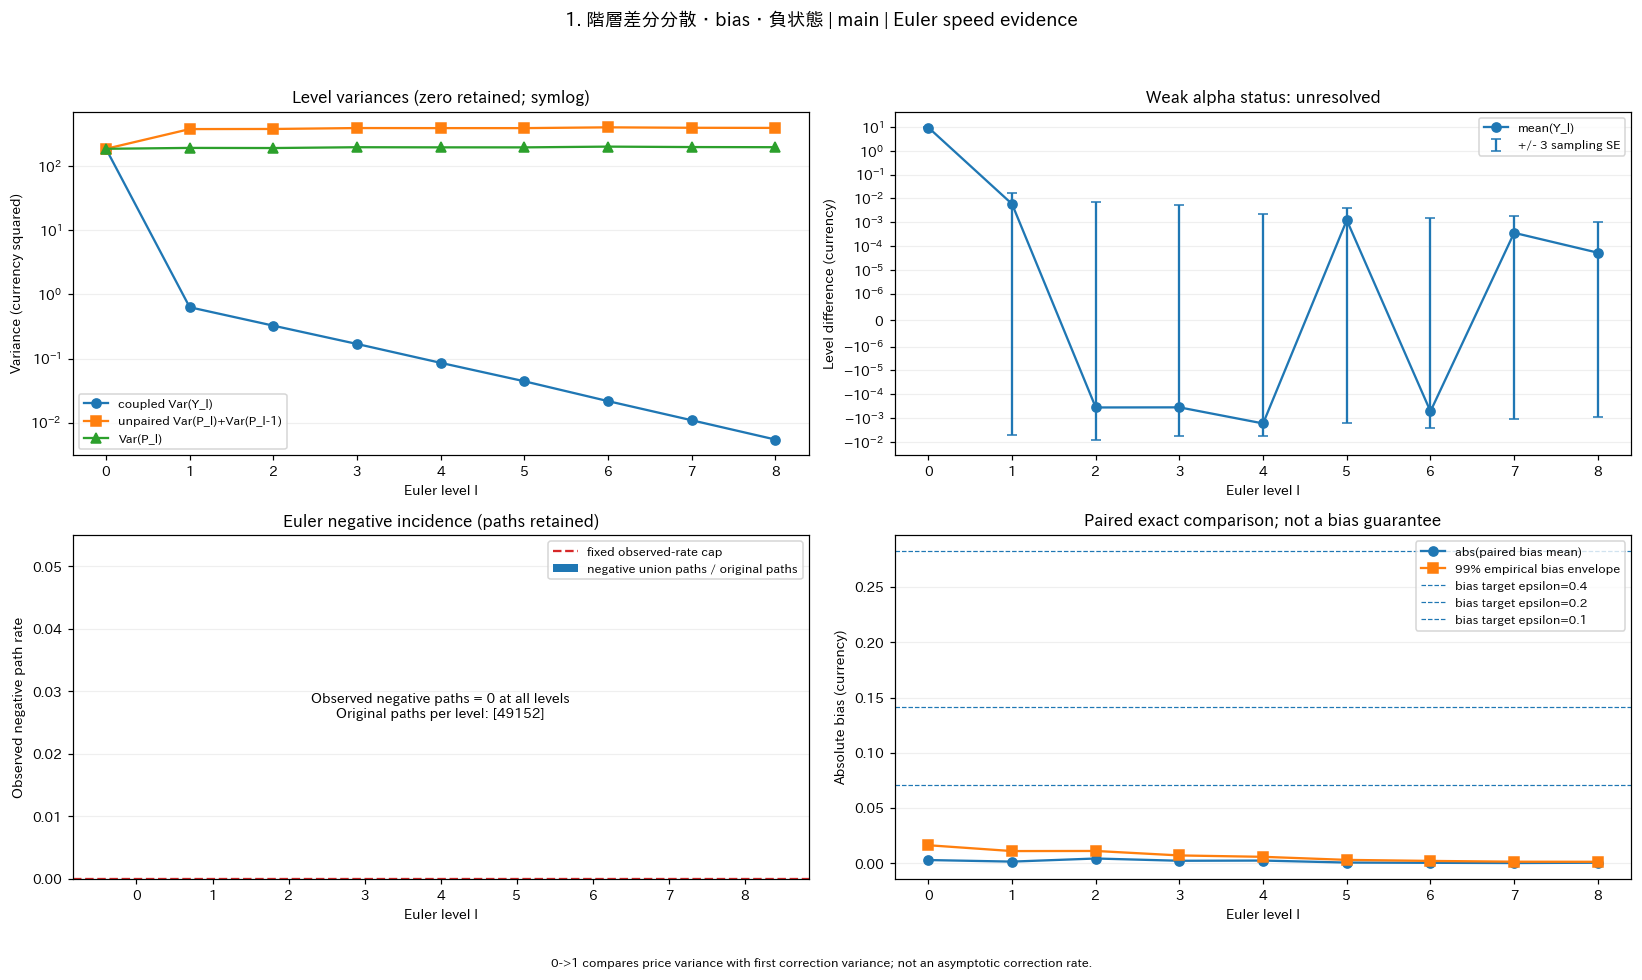

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
if pilot is None:
    for ax in axes.ravel():
        ax.set_axis_off()
        ax.text(.5, .5, "fixture: pilotなし\nNo accepted pilot moments in this fixture",
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
    print("pilotなし: fixtureの図1は空欄を明示。主実験のpilot値へ昇格しません。")
else:
    levels = pilot["level_summaries"]
    x = np.array([row["level"] for row in levels])
    for key, title, marker in [("coupled_variance", "coupled Var(Y_l)", "o"),
                               ("uncoupled_variance", "unpaired Var(P_l)+Var(P_l-1)", "s")]:
        axes[0, 0].plot(x, [row[key] for row in levels], marker + "-", label=title)
    axes[0, 0].plot(x, [row["fine"]["variance"] for row in levels], "^-", label="Var(P_l)")
    axes[0, 0].set_yscale("symlog", linthresh=1e-12)
    axes[0, 0].set_title("Level variances (zero retained; symlog)")
    axes[0, 0].set_ylabel("Variance (currency squared)")
    axes[0, 0].legend(fontsize=8)
    axes[0, 1].plot(x, [row["difference"]["mean"] for row in levels], "o-", label="mean(Y_l)")
    axes[0, 1].errorbar(x, [row["difference"]["mean"] for row in levels],
                       yerr=[3*row["difference"]["standard_error"] for row in levels],
                       fmt="none", capsize=3, label="+/- 3 sampling SE")
    axes[0, 1].set_yscale("symlog", linthresh=1e-6)
    axes[0, 1].set_title("Weak alpha status: " + pilot["rates"]["alpha_status"])
    axes[0, 1].set_ylabel("Level difference (currency)")
    axes[0, 1].legend(fontsize=8)
    axes[1, 0].bar(x, [row["negative_path_rate"] for row in levels],
                   label="negative union paths / original paths")
    axes[1, 0].axhline(protocol["pilot"]["negative_path_rate_cap"], color="tab:red",
                       linestyle="--", label="fixed observed-rate cap")
    axes[1, 0].set_title("Euler negative incidence (paths retained)")
    axes[1, 0].set_ylabel("Observed negative path rate")
    axes[1, 0].set_ylim(bottom=0)
    if all(row["negative_paths"] == 0 for row in levels):
        denominators = sorted({row["count"] for row in levels})
        axes[1, 0].text(.5, .5, "Observed negative paths = 0 at all levels\n"
                        + "Original paths per level: " + str(denominators),
                        ha="center", va="center", transform=axes[1, 0].transAxes)
    axes[1, 0].legend(fontsize=8)
    axes[1, 1].plot(x, [abs(row["bias"]["mean"]) for row in levels], "o-", label="abs(paired bias mean)")
    axes[1, 1].plot(x, [row["bias_bound"] for row in levels], "s-", label="99% empirical bias envelope")
    for epsilon in protocol["epsilon"]:
        axes[1, 1].axhline(epsilon/np.sqrt(2), linestyle="--", linewidth=.8,
                           label=f"bias target epsilon={epsilon:g}")
    axes[1, 1].set_title("Paired exact comparison; not a bias guarantee")
    axes[1, 1].set_ylabel("Absolute bias (currency)")
    axes[1, 1].legend(fontsize=8)
    for ax in axes.ravel():
        ax.set_xlabel("Euler level l")
        ax.set_xticks(x)
        ax.grid(axis="y", alpha=.2)
    print("alpha windows:", pilot["rates"]["alpha_windows"], "| beta:", pilot["rates"]["beta_adjacent"])
    print("beta隣接比の0→1はY0価格分散と初回補正分散の比較で、補正分散の漸近収束率ではありません。")
    print("level 1以降も観測比です。alphaは保存されたunresolved状態を維持します。")
    fig.text(.5, .014, "0->1 compares price variance with first correction variance; not an asymptotic correction rate.",
             ha="center", fontsize=8)
    table(["level", "元paths", "negative paths", "negative fine states / denominator",
           "negative coarse states / denominator"],
          [[row["level"], row["count"], row["negative_paths"],
            f"{row['fine_negative_states']}/{row['fine_state_denominator']}",
            f"{row['coarse_negative_states']}/{row['coarse_state_denominator']}"] for row in levels])
finish_figure(fig, "1. 階層差分分散・bias・負状態")


## 2. 経路配分・予算・費用share

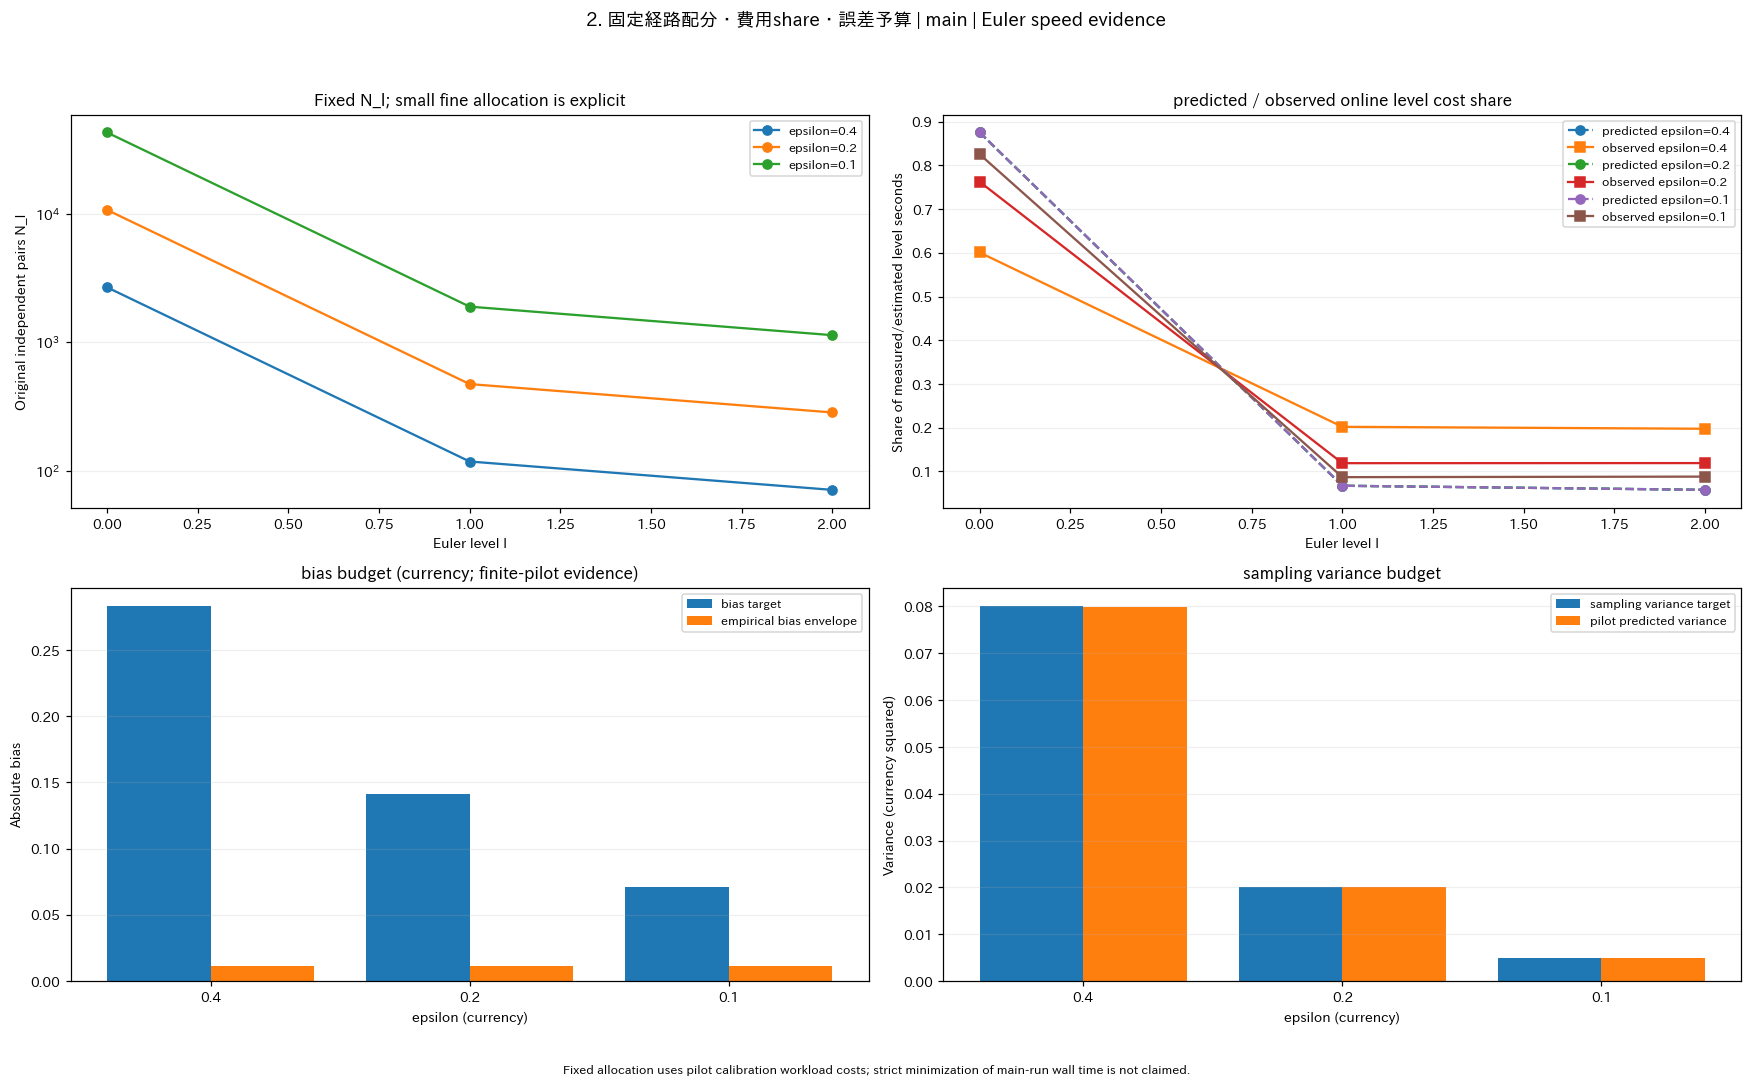

C_lはpilot較正workload（fine/coarse/exact/biasの5種momentsとcovariance）の計時です。
主runはdifferenceの1種momentsを集計します。pilot較正workloadに基づく固定配分で、主run実時間の厳密な最小化は主張しません。


| epsilon | method | 必要pilot等の秒 | main秒 | cold秒 | amortized K=10秒 | amortized K=100秒 |
| --- | --- | --- | --- | --- | --- | --- |
| 0.4 | Euler MLMC | 57.5513 | 0.000680168 | 57.552 | 5.75581 | 0.576194 |
| 0.4 | plain Euler | 55.9146 | 0.000713229 | 55.9153 | 5.59217 | 0.559859 |
| 0.4 | exact terminal | 53.7315 | 0.000179167 | 53.7317 | 5.37333 | 0.537494 |
| 0.4 | fixed-pilot CV | 53.7315 | 0.000118968 | 53.7316 | 5.37327 | 0.537434 |
| 0.2 | Euler MLMC | 57.5513 | 0.00165787 | 57.553 | 5.75679 | 0.577171 |
| 0.2 | plain Euler | 55.9146 | 0.00232265 | 55.9169 | 5.59378 | 0.561468 |
| 0.2 | exact terminal | 53.7315 | 0.000362628 | 53.7319 | 5.37352 | 0.537678 |
| 0.2 | fixed-pilot CV | 53.7315 | 0.000143361 | 53.7317 | 5.3733 | 0.537459 |
| 0.1 | Euler MLMC | 57.5513 | 0.00535048 | 57.5566 | 5.76048 | 0.580863 |
| 0.1 | plain Euler | 55.9146 | 0.00873895 | 55.9233 | 5.60019 | 0.567884 |
| 0.1 | exact terminal | 53.7315 | 0.00110679 | 53.7326 | 5.37426 | 0.538422 |
| 0.1 | fixed-pilot CV | 53.7315 | 0.000310644 | 53.7318 | 5.37346 | 0.537626 |

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
epsilon_labels, bias_used, bias_targets, sampling_used, sampling_targets = [], [], [], [], []
unavailable = []
for budget, (allocation, cell) in enumerate(zip(record["allocations"], record["budget_cells"])):
    epsilon = allocation["epsilon"]
    epsilon_labels.append(f"{epsilon:g}")
    counts = allocation["mlmc_paths"]
    if counts is None:
        print("unavailable allocation:", epsilon, allocation["status"], allocation["reason"])
        unavailable.append(f"epsilon={epsilon:g}: {allocation['status']}")
        continue
    levels = np.arange(len(counts))
    axes[0, 0].plot(levels, counts, "o-", label=f"epsilon={epsilon:g}")
    observed = np.zeros(len(counts))
    for run in cell["methods"]["mlmc"]["runs"]:
        for level in run["levels"]:
            if 0 <= level["level"] < len(counts):
                observed[level["level"]] += np.asarray(arrays[level["timings_key"]]).sum()
    allocation_info = allocation.get("variance_cost_allocation")
    if allocation_info:
        predicted = np.asarray(counts) * np.asarray(allocation_info["median_seconds_per_pair"])
        predicted_share = predicted/predicted.sum() if predicted.sum() else np.zeros_like(predicted)
        axes[0, 1].plot(levels, predicted_share, "o--", label=f"predicted epsilon={epsilon:g}")
    elif mode == "fixture":
        print("fixture: predicted pilot cost share unavailable")
    observed_share = observed/observed.sum() if observed.sum() else np.zeros_like(observed)
    axes[0, 1].plot(levels, observed_share, "s-", label=f"observed epsilon={epsilon:g}")
    bias_targets.append(allocation["bias_target"])
    bias_used.append(np.nan if allocation["bias_bound"] is None else allocation["bias_bound"])
    sampling_targets.append(allocation["sampling_variance"])
    sampling_used.append((allocation_info or {}).get("estimated_sampling_variance", np.nan))
if unavailable:
    axes[0, 0].text(.02, .98, "\n".join(unavailable), transform=axes[0, 0].transAxes, va="top")
axes[0, 0].set_title("Fixed N_l; small fine allocation is explicit")
axes[0, 0].set_ylabel("Original independent pairs N_l")
axes[0, 0].set_yscale("symlog", linthresh=1)
axes[0, 1].set_title("predicted / observed online level cost share")
axes[0, 1].set_ylabel("Share of measured/estimated level seconds")
for ax in axes[0]:
    ax.set_xlabel("Euler level l")
    handles, _ = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=.2)
valid_labels = [f"{row['epsilon']:g}" for row in record["allocations"] if row["mlmc_paths"] is not None]
positions = np.arange(len(valid_labels))
axes[1, 0].bar(positions-.2, bias_targets, .4, label="bias target")
axes[1, 0].bar(positions+.2, bias_used, .4, label="empirical bias envelope")
axes[1, 0].set_title("bias budget (currency; finite-pilot evidence)")
axes[1, 0].set_ylabel("Absolute bias")
axes[1, 1].bar(positions-.2, sampling_targets, .4, label="sampling variance target")
axes[1, 1].bar(positions+.2, sampling_used, .4, label="pilot predicted variance")
axes[1, 1].set_title("sampling variance budget")
if not np.isfinite(sampling_used).all():
    axes[1, 1].text(.02, .96, "Saved pilot predicted variance unavailable",
                    transform=axes[1, 1].transAxes, va="top", fontsize=8)
axes[1, 1].set_ylabel("Variance (currency squared)")
for ax in axes[1]:
    ax.set_xticks(positions, valid_labels)
    ax.set_xlabel("epsilon (currency)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=.2)
fig.text(.5, .014, "Fixed allocation uses pilot calibration workload costs; strict minimization of main-run wall time is not claimed.",
         ha="center", fontsize=8)
finish_figure(fig, "2. 固定経路配分・費用share・誤差予算")
print("C_lはpilot較正workload（fine/coarse/exact/biasの5種momentsとcovariance）の計時です。")
print("主runはdifferenceの1種momentsを集計します。pilot較正workloadに基づく固定配分で、主run実時間の厳密な最小化は主張しません。")
offline_rows = []
for epsilon in record["epsilons"]:
    for name in names:
        account = costs["methods"][str(epsilon)][name]
        offline_rows.append([epsilon, labels[name], number(account["offline_s"]),
                             number(account["main_mean_s"]), number(account["cold_mean_s"]),
                             number(account["amortized_mean_s"]["10"]),
                             number(account["amortized_mean_s"]["100"])])
table(["epsilon", "method", "必要pilot等の秒", "main秒", "cold秒", "amortized K=10秒",
       "amortized K=100秒"], offline_rows)


## 3. RMSE対費用と強い解析比較器

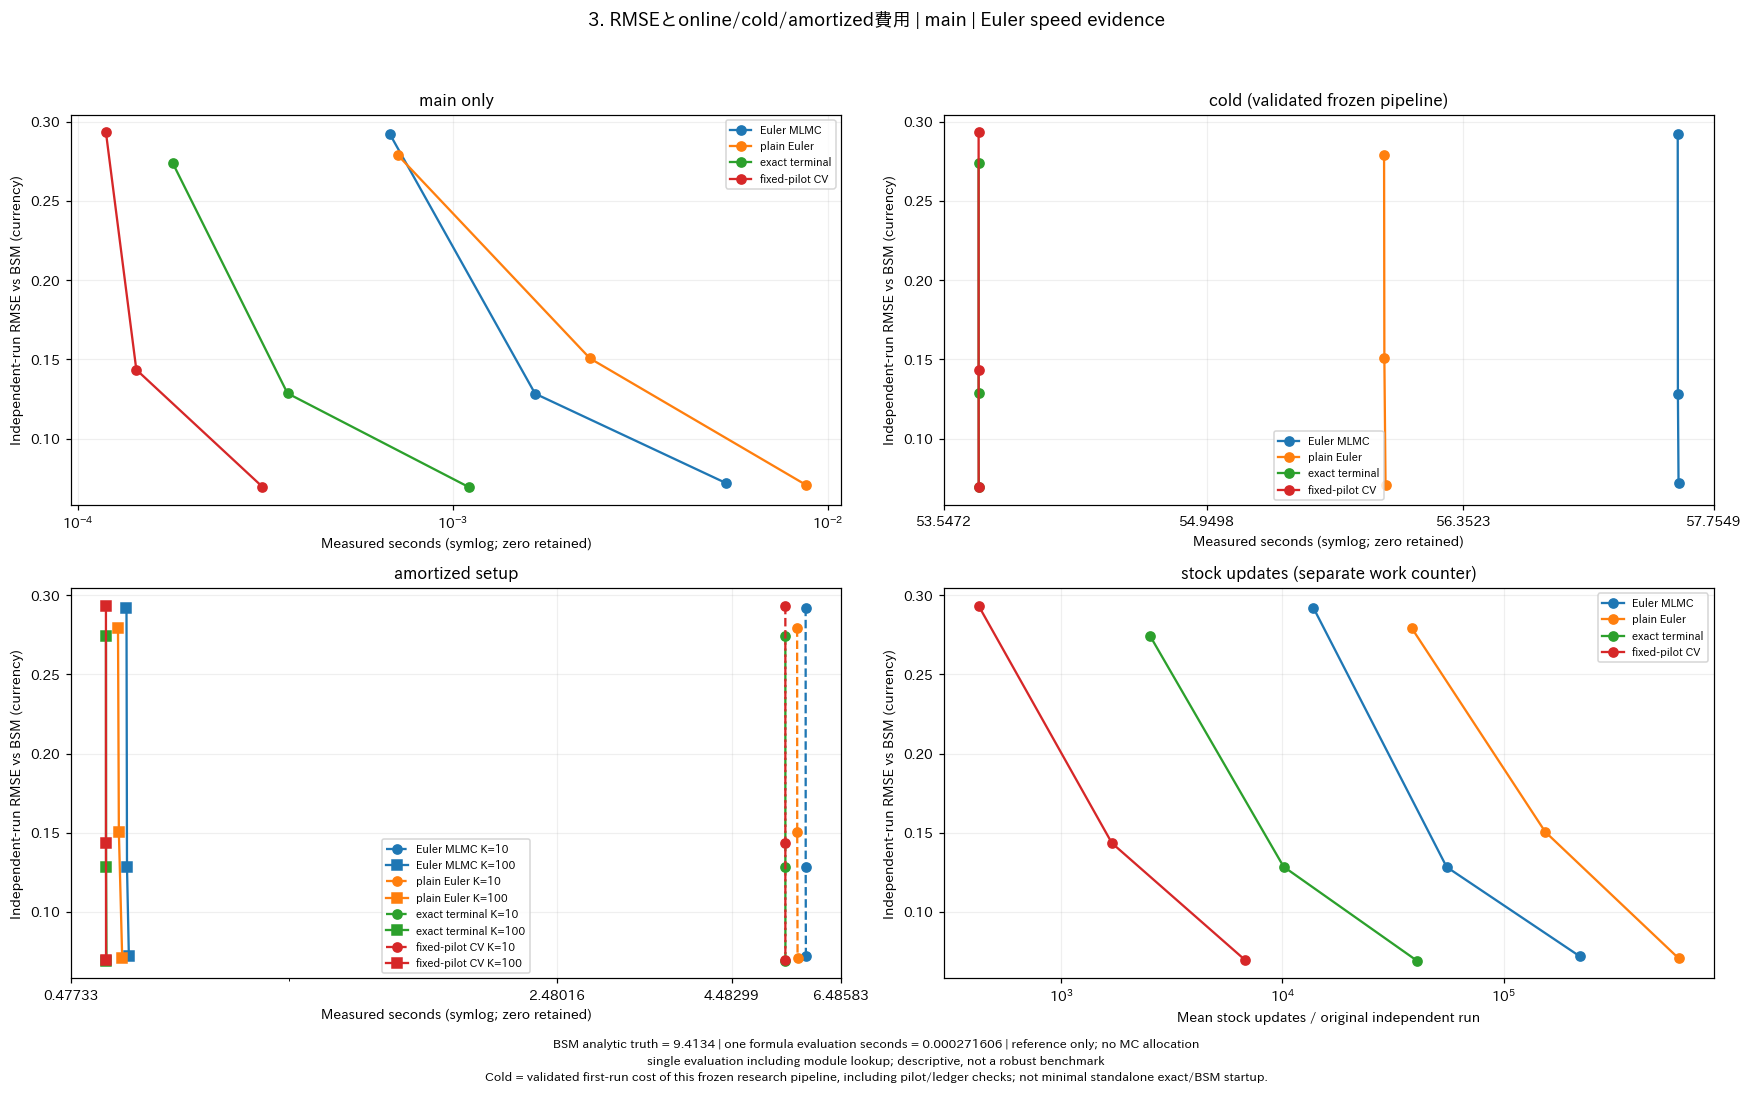

cold: この凍結研究pipelineの検証込み初回費用。全pilot・台帳検証を含み、exact/BSM単独の数学的必要起動費用とは呼びません。
main-only seconds are plotted separately; independent BSM single-evaluation seconds = 0.000271606 (descriptive, not a robust benchmark).
Saved expense registry preserves validation expense IDs and scopes.
BSM exact terminal is a strong comparator; MLMC is not required to beat it.
Pilot/serialization/fresh cost are distinct; wall seconds, normals and stock updates are different units.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for name in names:
    rmse, main_seconds, cold_seconds, ten_seconds, hundred_seconds, updates = [], [], [], [], [], []
    for cell in record["budget_cells"]:
        method = cell["methods"][name]
        if method["status"] != "valid" or method["errors"] is None:
            print("failed/unavailable method retained:", cell["epsilon"], name,
                  method["reason"], "original runs", len(method["runs"]))
            continue
        account = costs["methods"][str(cell["epsilon"])][name]
        rmse.append(method["errors"]["rmse"])
        main_seconds.append(account["main_mean_s"])
        cold_seconds.append(account["cold_mean_s"])
        ten_seconds.append(account["amortized_mean_s"]["10"])
        hundred_seconds.append(account["amortized_mean_s"]["100"])
        original_updates = [sum(int(np.asarray(arrays[level["counters_key"]])[:, 0].sum())
                                for level in run["levels"]) for run in method["runs"]]
        updates.append(float(np.mean(original_updates)))
    if rmse:
        axes[0, 0].plot(main_seconds, rmse, "o-", color=colors[name], label=labels[name])
        axes[0, 1].plot(cold_seconds, rmse, "o-", color=colors[name], label=labels[name])
        axes[1, 0].plot(ten_seconds, rmse, "o--", color=colors[name], label=labels[name]+" K=10")
        axes[1, 0].plot(hundred_seconds, rmse, "s-", color=colors[name], label=labels[name]+" K=100")
        axes[1, 1].plot(updates, rmse, "o-", color=colors[name], label=labels[name])
for ax, title in zip(axes.ravel(), ["main only", "cold (validated frozen pipeline)", "amortized setup",
                                    "stock updates (separate work counter)"]):
    ax.set_title(title)
    ax.set_xscale("symlog", linthresh=1e-6 if ax is not axes[1, 1] else 1)
    ax.set_xlabel("Measured seconds (symlog; zero retained)" if ax is not axes[1, 1]
                  else "Mean stock updates / original independent run")
    low, high = ax.get_xlim()
    visible_ticks = [value for value in ax.get_xticks() if low <= value <= high]
    if len(visible_ticks) < 2:
        ax.set_xticks(np.linspace(low, high, 4))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:.6g}"))
    ax.set_ylabel("Independent-run RMSE vs BSM (currency)")
    handles, _ = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=7)
    ax.grid(alpha=.2)
truths = [cell["truth"] for cell in record["budget_cells"]]
analytic = record.get("analytic_reference", {})
analytic_seconds = analytic.get("seconds")
fig.text(.5, .037, "BSM analytic truth = "+number(truths[0] if truths else None)
         +" | one formula evaluation seconds = "+number(analytic_seconds)
         +" | reference only; no MC allocation", ha="center", fontsize=8)
fig.text(.5, .022, analytic.get("scope", "Analytic timing unavailable in this saved bundle"),
         ha="center", fontsize=8)
fig.text(.5, .007, "Cold = validated first-run cost of this frozen research pipeline, including pilot/ledger checks; not minimal standalone exact/BSM startup.",
         ha="center", fontsize=8)
finish_figure(fig, "3. RMSEとonline/cold/amortized費用")
print("cold: この凍結研究pipelineの検証込み初回費用。全pilot・台帳検証を含み、exact/BSM単独の数学的必要起動費用とは呼びません。")
print("main-only seconds are plotted separately; independent BSM single-evaluation seconds =",
      number(analytic_seconds), "(descriptive, not a robust benchmark).")
print("Saved expense registry preserves validation expense IDs and scopes.")
print("BSM exact terminal is a strong comparator; MLMC is not required to beat it.")
print("Pilot/serialization/fresh cost are distinct; wall seconds, normals and stock updates are different units.")


## 4. 近似CIの被覆率・幅・元の分母

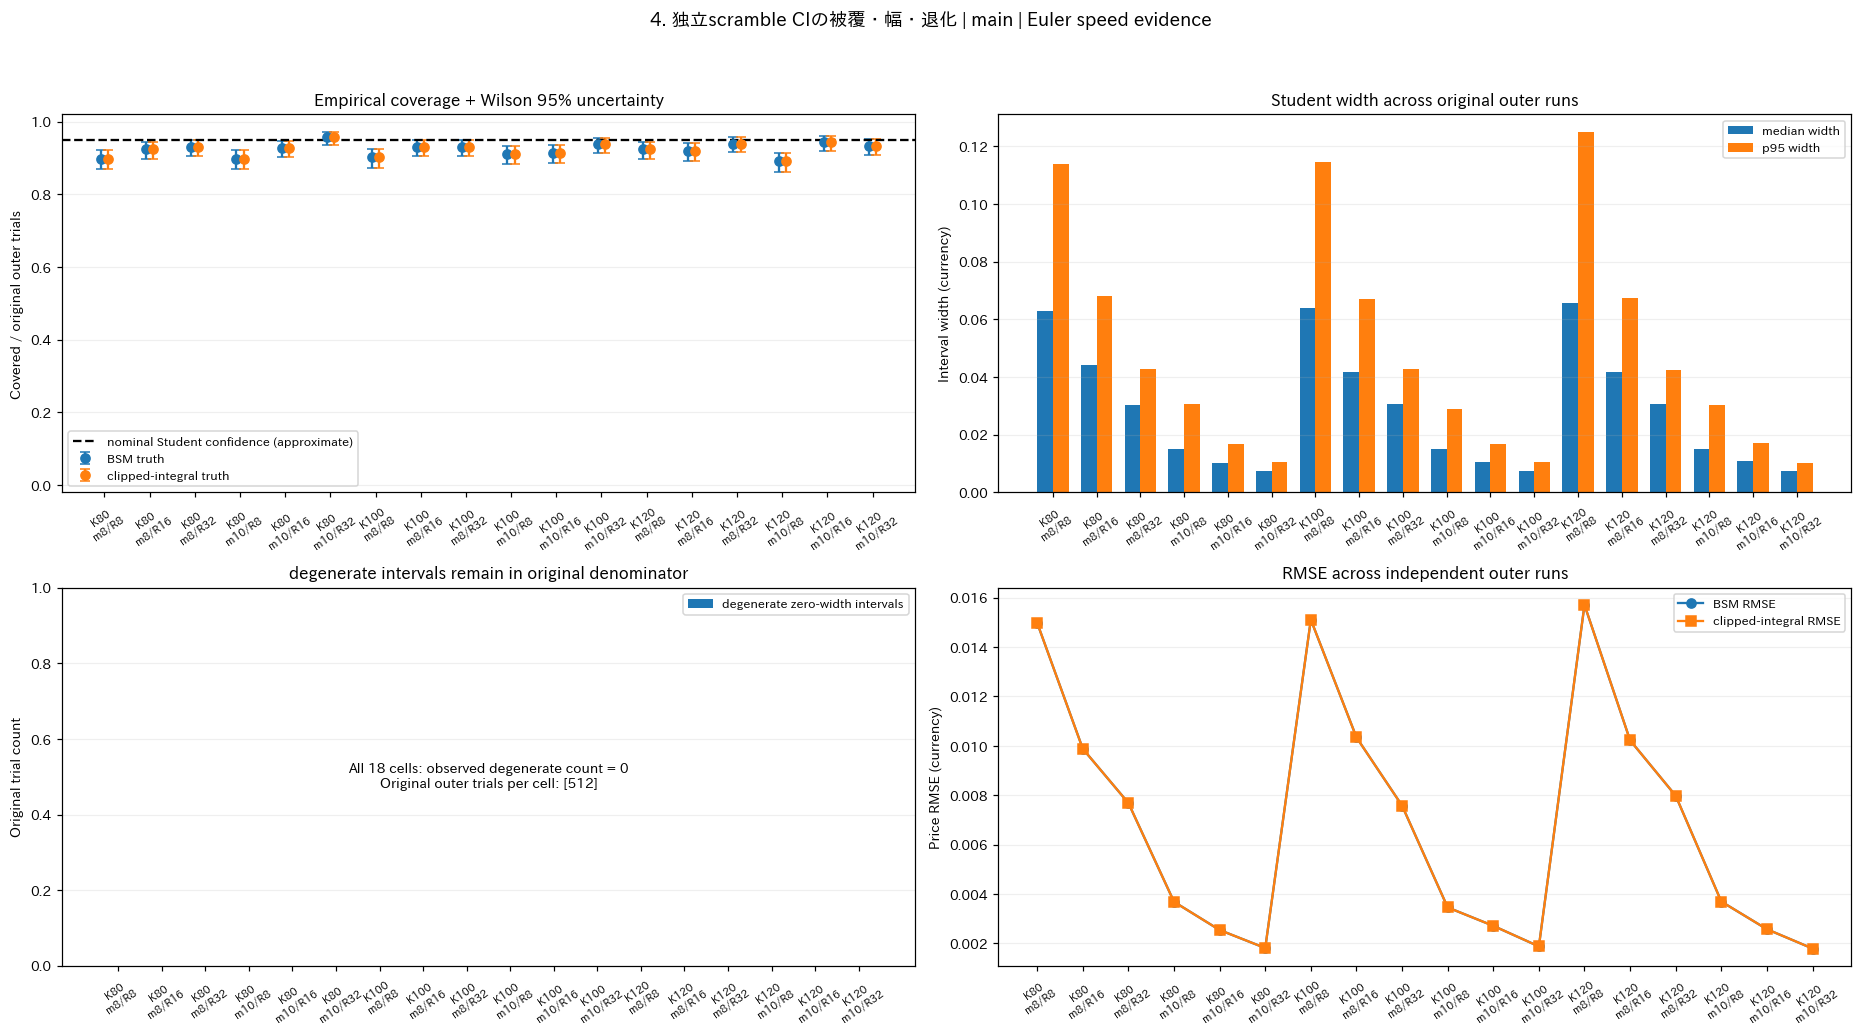

| epsilon | Euler method | 元outer分母 | sampling CI vs BSM | bias-aware CI vs BSM | 失敗理由 |
| --- | --- | --- | --- | --- | --- |
| 0.4 | Euler MLMC | 256 | 0.921875 | 0.929688 | None |
| 0.4 | plain Euler | 256 | 0.949219 | 0.953125 | None |
| 0.2 | Euler MLMC | 256 | 0.964844 | 0.972656 | None |
| 0.2 | plain Euler | 256 | 0.953125 | 0.957031 | None |
| 0.1 | Euler MLMC | 256 | 0.953125 | 0.960938 | None |
| 0.1 | plain Euler | 256 | 0.941406 | 0.960938 | None |

BSM coverage includes discretization bias; sampling interval targets the Euler expectation.
RQMC t intervals use R independent scramble means, not R*2**m independent samples.
Wilson intervals describe finite outer-trial coverage uncertainty, not a universal t-CI guarantee.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
cells = record["coverage_cells"]
positions = np.arange(len(cells))
ticklabels = [f"K{cell['strike']:g}\nm{cell['power']}/R{cell['scrambles']}" for cell in cells]
for target, offset, color in [("BSM", -.08, "tab:blue"), ("clip", .08, "tab:orange")]:
    coverage = np.full(len(cells), np.nan)
    lower, upper = coverage.copy(), coverage.copy()
    for i, cell in enumerate(cells):
        summary = cell["coverage_"+target]
        if summary:
            coverage[i] = summary["coverage"]
            lower[i], upper[i] = summary["wilson95"]
        else:
            print("failed RQMC cell:", ticklabels[i], cell["reason"],
                  "| original outer denominator:", cell["outer_runs"])
    axes[0, 0].errorbar(positions+offset, coverage,
                       yerr=np.array([coverage-lower, upper-coverage]),
                       fmt="o", capsize=3, color=color,
                       label="BSM truth" if target == "BSM" else "clipped-integral truth")
axes[0, 0].axhline(protocol["rqmc"]["confidence"], color="black", linestyle="--",
                   label="nominal Student confidence (approximate)")
axes[0, 0].set_ylim(-.02, 1.02)
axes[0, 0].set_title("Empirical coverage + Wilson 95% uncertainty")
axes[0, 0].set_ylabel("Covered / original outer trials")
axes[0, 0].legend(fontsize=8)
medians = [np.nan if cell["coverage_BSM"] is None else cell["coverage_BSM"]["median_width"] for cell in cells]
p95s = [np.nan if cell["coverage_BSM"] is None else cell["coverage_BSM"]["p95_width"] for cell in cells]
axes[0, 1].bar(positions-.18, medians, .36, label="median width")
axes[0, 1].bar(positions+.18, p95s, .36, label="p95 width")
axes[0, 1].set_title("Student width across original outer runs")
axes[0, 1].set_ylabel("Interval width (currency)")
axes[0, 1].legend(fontsize=8)
degenerate = [np.nan if cell["coverage_BSM"] is None else cell["coverage_BSM"]["degenerate"] for cell in cells]
for i, cell in enumerate(cells):
    if cell["status"] != "valid":
        axes[0, 0].text(i, .03, "failed", ha="center", fontsize=7, rotation=90)
        axes[1, 0].text(i, 0, "failed", ha="center", va="bottom", fontsize=7, rotation=90)
axes[1, 0].bar(positions, degenerate, label="degenerate zero-width intervals")
axes[1, 0].set_title("degenerate intervals remain in original denominator")
axes[1, 0].set_ylabel("Original trial count")
finite_degenerate = [value for value in degenerate if np.isfinite(value)]
axes[1, 0].set_ylim(0, max(1, max(finite_degenerate, default=0)*1.1))
if cells and len(finite_degenerate) == len(cells) and all(value == 0 for value in finite_degenerate):
    original_trials = sorted({cell["outer_runs"] for cell in cells})
    axes[1, 0].text(.5, .5, "All " + str(len(cells)) + " cells: observed degenerate count = 0\n"
                   + "Original outer trials per cell: " + str(original_trials),
                   ha="center", va="center", transform=axes[1, 0].transAxes)
axes[1, 0].legend(fontsize=8)
for target, marker in [("BSM", "o-"), ("clip", "s-")]:
    values = [np.nan if cell["errors_"+target] is None else cell["errors_"+target]["rmse"] for cell in cells]
    axes[1, 1].plot(positions, values, marker,
                   label="BSM RMSE" if target == "BSM" else "clipped-integral RMSE")
axes[1, 1].set_title("RMSE across independent outer runs")
axes[1, 1].set_ylabel("Price RMSE (currency)")
axes[1, 1].legend(fontsize=8)
for ax in axes.ravel():
    ax.set_xticks(positions, ticklabels, fontsize=7, rotation=35)
    ax.grid(axis="y", alpha=.2)
finish_figure(fig, "4. 独立scramble CIの被覆・幅・退化")
rows = []
for cell in record["budget_cells"]:
    for name in ["mlmc", "plain_euler"]:
        method = cell["methods"][name]
        rows.append([cell["epsilon"], labels[name], record["main_repetitions"],
                     number((method["coverage"] or {}).get("coverage")),
                     number((method["bias_aware_coverage"] or {}).get("coverage")),
                     method["reason"]])
table(["epsilon", "Euler method", "元outer分母", "sampling CI vs BSM",
       "bias-aware CI vs BSM", "失敗理由"], rows)
print("BSM coverage includes discretization bias; sampling interval targets the Euler expectation.")
print("RQMC t intervals use R independent scramble means, not R*2**m independent samples.")
print("Wilson intervals describe finite outer-trial coverage uncertainty, not a universal t-CI guarantee.")


## 採否と限界

- Student区間は近似で、非有界callに有界integrandのEBCI/HBCI保証を移しません。
- Eulerのsampling CI、時間離散化bias、finite-pilotの経験的bias envelopeを分離します。
- RQMCの統計単位は独立scramble推定値です。点の総数を独立標本数にはしません。
- 元の試行分母と失敗理由を保持し、失敗cellや負のEuler経路を除去しません。
- seed/clip、較正ではなくfixed pilotのCV beta、主条件・配分は主比較前に固定します。
- main only、cold、amortized、研究の保管・fresh再生費用を区別します。coldはこの凍結研究pipelineの検証込み初回費用で、全pilot・台帳検証を含みます。exact/BSM単独に数学的に必要な起動費用とは呼びません。
- main-only秒と独立BSM単回秒を並記します。BSMの単回計時は記述値で、benchmark保証ではありません。保存expensesで検証費用のIDとscopeを確認できます。単一seed絶対誤差をRMSEと呼びません。
- C_lはpilot較正workload（5種momentsとcovariance）の費用です。mainはdifferenceの1種momentsを集計するため、固定配分が主run実時間を厳密に最小化するとは主張しません。
- betaの0→1隣接比はY0価格分散と初回補正分散の比較で、補正分散の漸近収束率ではありません。後続の比も観測比で、alphaのunresolved状態を保持します。
- 記録カテゴリの研究費用合計はCLI総wallではありません。post-run check・decision・JSON書出し・startup等の未記録段階を区別し、独立stopwatch receiptがあれば保存recordのdigestを照合してwall_sとunaccounted_overhead_sを表示します。receiptなしはpendingです。
- 計算checkerは独立研究受入の代替ではありません。fixtureは未受入で、研究の優位性を示しません。
- Heston算術Asianは専用revisionの後続段階です。このGBM v1の結果をその真値や完了として流用しません。
